In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt  

In [ ]:
#TASK1

url = "https://raw.githubusercontent.com/DAVE3625/Dave3625-2026/refs/heads/main/Lab2/data/stud.csv"
df = pd.read_csv(url, sep=',')
df.head()

,StudentID,Age,email,hrsStudy,FinalGrade
0,47412,20,s47412@oslomet.no,5,46.0
1,15077,22,s15077@oslomet.no,0,65.0
2,15467,27,s15467@oslomet.no,1,26.0
3,17907,21,s17907@oslomet.no,6,68.0
4,13352,333,s13352@oslomet.no,4,34.0


In [ ]:
#TASK2

df.isna().sum()

# Replace blank strings with real NaN
df = df.replace(r'^\s*$', np.nan, regex=True)
df.isna().sum()

# StudentID looks like "s12345" as text — strip the "s" and convert to int
df['StudentID'] = df['StudentID'].astype(str).str.replace('s', '', regex=False).astype(int)


# Drop any remaining rows with missing values (should get you to 48 entries)
df = df.dropna()

df.info()


<class 'pandas.DataFrame'>
Index: 47 entries, 0 to 49
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   StudentID   47 non-null     int64  
 1   Age         47 non-null     str    
 2   email       47 non-null     str    
 3   hrsStudy    47 non-null     str    
 4   FinalGrade  47 non-null     float64
dtypes: float64(1), int64(1), str(3)
memory usage: 2.2 KB


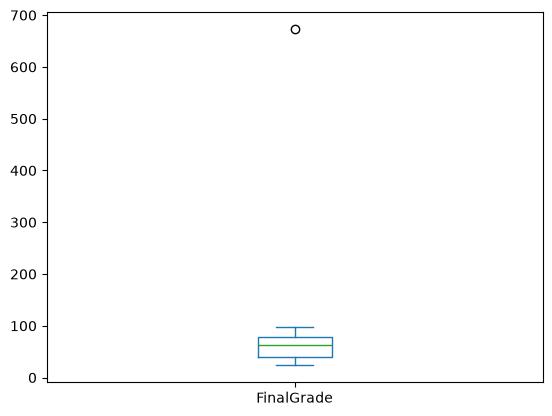

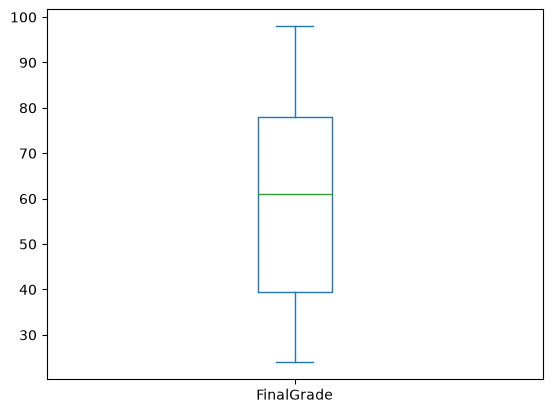

In [12]:
#TASK3

df["FinalGrade"].plot.box()
plt.show()

z_scores = stats.zscore(df["FinalGrade"])
abs_z_scores = abs(z_scores)
filtered_entries = (abs_z_scores < 3)
df = df[filtered_entries]

df["FinalGrade"].plot.box()
plt.show()

In [13]:
#TASK4
def to_grade(score):
    if score > 90:
        return 'A'
    elif score > 80:
        return 'B'
    elif score > 70:
        return 'C'
    elif score > 60:
        return 'D'
    elif score > 50:
        return 'E'
    else:
        return 'F'

df['Grade'] = df['FinalGrade'].apply(to_grade)
df.head()

,StudentID,Age,email,hrsStudy,FinalGrade,Grade
0,47412,20,s47412@oslomet.no,5,46.0,F
1,15077,22,s15077@oslomet.no,0,65.0,D
2,15467,27,s15467@oslomet.no,1,26.0,F
3,17907,21,s17907@oslomet.no,6,68.0,D
4,13352,333,s13352@oslomet.no,4,34.0,F


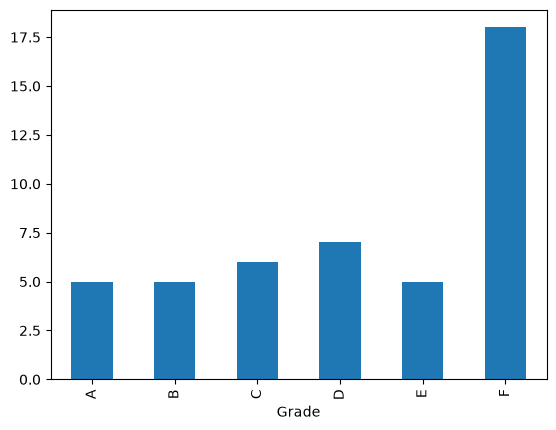

In [14]:
grade_order = ['A', 'B', 'C', 'D', 'E', 'F']
df['Grade'].value_counts().reindex(grade_order).plot.bar()
plt.xlabel('Grade')
plt.show()